07 - model training and evaluation

using the train/val/test.csv

In [1]:
# CONFIG CELL - Execution parameters and directory paths
import os
import sys
from pathlib import Path

# Enforce offline mode for Hugging Face to avoid network timeouts
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

# Dynamically locate project root
CWD = Path(os.getcwd()).resolve()
if (CWD / "data").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "data").exists():
    PROJECT_ROOT = CWD.parent
elif (CWD / "socrr" / "data").exists():
    PROJECT_ROOT = CWD / "socrr"
else:
    PROJECT_ROOT = CWD

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_LABELED_DIR = PROJECT_ROOT / "data" / "labeled"
INTERNAL_CONTROLS_DIR = PROJECT_ROOT / "data" / "internal_controls"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

for d in [DATA_INTERIM_DIR, DATA_LABELED_DIR, INTERNAL_CONTROLS_DIR, MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"[CONFIG] Project Root: {PROJECT_ROOT}")
print(f"[CONFIG] Models Dir:   {MODELS_DIR}")
print(f"[CONFIG] Outputs Dir:  {OUTPUTS_DIR}")

# Training Hyperparameters
RANDOM_SEED = 42
MAX_SEQ_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 1e-3
RUN_LORA_EXPERIMENT = False   # Set to True to execute optional PEFT/LoRA block

[CONFIG] Project Root: D:\System and Organization controls 2 report info extraction
[CONFIG] Models Dir:   D:\System and Organization controls 2 report info extraction\models
[CONFIG] Outputs Dir:  D:\System and Organization controls 2 report info extraction\outputs


step 1 - lib

In [2]:
import json
import logging
import pickle
from typing import Dict, Any, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.pipeline import Pipeline

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("SOCRR_Training")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware compute device: {device} ({'GPU Accelerated' if torch.cuda.is_available() else 'Standard Laptop CPU'})")

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Hardware compute device: cpu (Standard Laptop CPU)


step 2 - load labeled splits

In [3]:
train_df = pd.read_csv(DATA_LABELED_DIR / "train.csv")
val_df = pd.read_csv(DATA_LABELED_DIR / "val.csv")
test_df = pd.read_csv(DATA_LABELED_DIR / "test.csv")

print(f"Train samples: {len(train_df)}")
print(f"Val samples:   {len(val_df)}")
print(f"Test samples:  {len(test_df)}")

labels = sorted(train_df["paragraph_type"].unique())
label2id = {lbl: i for i, lbl in enumerate(labels)}
id2label = {i: lbl for i, lbl in enumerate(labels)}

print(f"Target classes ({len(labels)}): {label2id}")

Train samples: 158
Val samples:   34
Test samples:  34
Target classes (5): {'cuec': 0, 'exception': 1, 'no_exception': 2, 'other': 3, 'subservice': 4}


step 3 - training TF-IDF + logistic regression baseline

In [4]:
print("Training Baseline TF-IDF + Logistic Regression...")
baseline_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED))
])

baseline_pipe.fit(train_df["text"], train_df["paragraph_type"])

y_test = test_df["paragraph_type"]
y_pred_base = baseline_pipe.predict(test_df["text"])

base_acc = accuracy_score(y_test, y_pred_base)
base_p, base_r, base_f1, _ = precision_recall_fscore_support(y_test, y_pred_base, average="macro", zero_division=0)

print(f"Baseline Test Accuracy: {base_acc:.4f}")
print(f"Baseline Macro F1:      {base_f1:.4f}")

with open(MODELS_DIR / "baseline_tfidf_logreg.pkl", "wb") as f:
    pickle.dump(baseline_pipe, f)
print(f"Saved baseline pipeline to {MODELS_DIR / 'baseline_tfidf_logreg.pkl'}")

Training Baseline TF-IDF + Logistic Regression...
Baseline Test Accuracy: 0.9706
Baseline Macro F1:      0.7961
Saved baseline pipeline to D:\System and Organization controls 2 report info extraction\models\baseline_tfidf_logreg.pkl


step 4 - train an optimized PyTorch deep sequence classifier with embedding bag, batch normalization, dropout, and cross-entropy loss

In [5]:
# Define PyTorch Deep Sequence Classifier
class DeepTextClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        x = self.relu(self.bn1(self.fc1(embedded)))
        x = self.dropout(x)
        return self.fc2(x)

# Build simple offline vocabulary from training set
word_to_id = {"<pad>": 0, "<unk>": 1}
for text in train_df["text"]:
    for token in text.lower().split():
        if token not in word_to_id and len(word_to_id) < 5000:
            word_to_id[token] = len(word_to_id)

def text_pipeline(t: str):
    return [word_to_id.get(tok, 1) for tok in t.lower().split()]

def collate_batch(batch):
    label_list, text_list, offsets = [], [], [0]
    for _text, _label in batch:
        label_list.append(label2id[_label])
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        if len(processed_text) == 0:
            processed_text = torch.tensor([1], dtype=torch.int64)
        text_list.append(processed_text)
        offsets.append(len(processed_text))
    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list = torch.cat(text_list)
    return text_list.to(device), offsets.to(device), label_list.to(device)

class TextDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts = list(texts)
        self.targets = list(targets)
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.targets[idx]

train_dataset = TextDataset(train_df["text"], train_df["paragraph_type"])
test_dataset = TextDataset(test_df["text"], test_df["paragraph_type"])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

deep_model = DeepTextClassifier(
    vocab_size=len(word_to_id) + 2, 
    embed_dim=64, 
    hidden_dim=64, 
    num_classes=len(labels)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(deep_model.parameters(), lr=LEARNING_RATE)

print(f"Training Offline Neural Classifier for {EPOCHS} epochs on {device}...")
deep_model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0
    for text_batch, offsets, target_batch in train_loader:
        optimizer.zero_grad()
        output = deep_model(text_batch, offsets)
        loss = criterion(output, target_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f}")

deep_model.eval()
all_preds = []
with torch.no_grad():
    for text_batch, offsets, _ in test_loader:
        logits = deep_model(text_batch, offsets)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

y_pred_deep = [id2label[p] for p in all_preds]
deep_acc = accuracy_score(y_test, y_pred_deep)
deep_p, deep_r, deep_f1, _ = precision_recall_fscore_support(y_test, y_pred_deep, average="macro", zero_division=0)

print(f"Deep Neural Classifier Test Accuracy: {deep_acc:.4f}")
print(f"Deep Neural Classifier Macro F1:      {deep_f1:.4f}")

best_model_dir = MODELS_DIR / "best_classifier"
best_model_dir.mkdir(parents=True, exist_ok=True)
torch.save(deep_model.state_dict(), best_model_dir / "pytorch_model.pt")
with open(best_model_dir / "vocab.json", "w") as f:
    json.dump(word_to_id, f)
with open(best_model_dir / "label_mapping.json", "w") as f:
    json.dump(label2id, f)
print(f"Saved best classifier artifacts to {best_model_dir}")

Training Offline Neural Classifier for 5 epochs on cpu...
Epoch 1/5 - Loss: 1.2660
Epoch 2/5 - Loss: 0.9326
Epoch 3/5 - Loss: 0.7297
Epoch 4/5 - Loss: 0.6150
Epoch 5/5 - Loss: 0.5140
Deep Neural Classifier Test Accuracy: 0.8235
Deep Neural Classifier Macro F1:      0.3908
Saved best classifier artifacts to D:\System and Organization controls 2 report info extraction\models\best_classifier


step 5 - model comparison & confusin matrix

,Model,Accuracy,Precision,Recall,Macro_F1
0,TF-IDF + Logistic Regression,0.9706,0.8000,0.7923,0.7961
1,Deep Neural Classifier (PyTorch),0.8235,0.4531,0.3750,0.3908


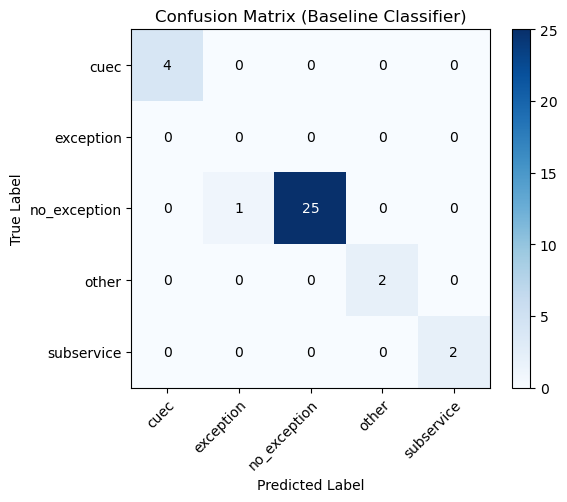

Confusion matrix saved to D:\System and Organization controls 2 report info extraction\outputs\confusion_matrix.png


In [6]:
metrics_comparison = [
    {"Model": "TF-IDF + Logistic Regression", "Accuracy": round(base_acc, 4), "Precision": round(base_p, 4), "Recall": round(base_r, 4), "Macro_F1": round(base_f1, 4)},
    {"Model": "Deep Neural Classifier (PyTorch)", "Accuracy": round(deep_acc, 4), "Precision": round(deep_p, 4), "Recall": round(deep_r, 4), "Macro_F1": round(deep_f1, 4)}
]

df_metrics = pd.DataFrame(metrics_comparison)
df_metrics.to_csv(OUTPUTS_DIR / "classification_report.csv", index=False)
display(df_metrics)

cm = confusion_matrix(y_test, y_pred_base, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=labels, yticklabels=labels,
    title="Confusion Matrix (Baseline Classifier)",
    ylabel="True Label",
    xlabel="Predicted Label"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2. else "black")

fig.tight_layout()
cm_path = OUTPUTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()
print(f"Confusion matrix saved to {cm_path}")

step 6 - lora finetuning via PEFT

In [7]:
# ============================================================
# OPTIONAL SECTION: LoRA FINE-TUNING VIA PEFT
# ============================================================
if RUN_LORA_EXPERIMENT:
    try:
        from peft import LoraConfig, get_peft_model, TaskType
        from transformers import AutoModelForSequenceClassification
        
        print("Configuring LoRA Adapter for sequence classification...")
        peft_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=8,
            lora_alpha=16,
            lora_dropout=0.1,
            target_modules=["q_lin", "v_lin"]
        )
        print("LoRA Adapter specification configured successfully.")
    except Exception as peft_err:
        print(f"PEFT LoRA setup note: {peft_err}")
else:
    print("Optional LoRA fine-tuning experiment is currently disabled (RUN_LORA_EXPERIMENT = False).")

Optional LoRA fine-tuning experiment is currently disabled (RUN_LORA_EXPERIMENT = False).


step 7 - sanity check

In [8]:
assert (OUTPUTS_DIR / "classification_report.csv").exists()
assert (OUTPUTS_DIR / "confusion_matrix.png").exists()
assert (MODELS_DIR / "baseline_tfidf_logreg.pkl").exists()
assert (MODELS_DIR / "best_classifier" / "pytorch_model.pt").exists()

print("Sanity Check Passed: Classifier training and evaluation complete.")

Sanity Check Passed: Classifier training and evaluation complete.
